In [1]:
import os

# ============================================================================
# OPTIONAL: Set CUDA paths if nvidia packages are installed
# This is optional - TensorFlow can run on CPU without these paths
# ============================================================================
try:
    import site
    # Try to find nvidia packages if they exist
    nvidia_base_paths = []
    for path in site.getsitepackages() + [site.getusersitepackages()]:
        nvidia_path = os.path.join(path, 'nvidia')
        if os.path.exists(nvidia_path):
            nvidia_base_paths.append(nvidia_path)
            print(f"✓ Found NVIDIA packages at: {nvidia_path}")
    
    if nvidia_base_paths:
        # Build CUDA library paths from found packages
        cuda_lib_dirs = []
        for nvidia_path in nvidia_base_paths:
            cuda_subdirs = ['cudnn', 'cublas', 'cufft', 'curand', 'cusolver', 'cusparse', 'nccl', 'nvjitlink']
            for subdir in cuda_subdirs:
                lib_path = os.path.join(nvidia_path, subdir, 'lib')
                if os.path.exists(lib_path):
                    cuda_lib_dirs.append(lib_path)
        
        if cuda_lib_dirs:
            existing_path = os.environ.get('LD_LIBRARY_PATH', '')
            os.environ['LD_LIBRARY_PATH'] = ":".join(cuda_lib_dirs) + ":" + existing_path
            print(f"✓ NVIDIA CUDA library paths injected ({len(cuda_lib_dirs)} directories)")
        else:
            print("⚠️ NVIDIA packages found but no lib folders detected - using CPU mode")
    else:
        print("⚠️ No NVIDIA packages found - will use CPU-only TensorFlow")
except Exception as e:
    print(f"⚠️ Could not detect NVIDIA packages: {e}")
    print("   This is OK - TensorFlow can run on CPU")

print("✓ Environment setup completed (GPU optional, CPU always available)")


✓ Found NVIDIA packages at: /home/arfat/.local/lib/python3.10/site-packages/nvidia
✓ NVIDIA CUDA library paths injected (7 directories)
✓ Environment setup completed (GPU optional, CPU always available)


In [2]:
data_dir = '/media/arfat/Design/Epileptic Seizure Dataset/chb-mit-scalp-eeg-database-1.0.0/chb-mit-scalp-eeg-database-1.0.0'

# Verify data directory exists
if not os.path.exists(data_dir):
    print(f"✗ Data directory not found: {data_dir}")
    print("\n⚠️  Please update data_dir to match your actual EEG dataset location.")
    print("   Common paths to check:")
    print("   - /media/arfat/Design/...")
    print("   - ~/Documents/chb-mit-eeg/")
    print("   - ./local_data/chb-mit-eeg/")
else:
    print(f"✓ Data directory confirmed: {data_dir}")


✓ Data directory confirmed: /media/arfat/Design/Epileptic Seizure Dataset/chb-mit-scalp-eeg-database-1.0.0/chb-mit-scalp-eeg-database-1.0.0


# STEP 1: IMPORTS

In [3]:
import mne
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV
from scipy import signal, stats
import joblib
import glob
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All libraries imported successfully.")
print(f"  TensorFlow version: {tf.__version__}")
print(f"  MNE version: {mne.__version__}")


2026-05-16 23:42:48.696726: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 23:42:48.700341: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-16 23:42:48.740033: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 23:42:49.695701: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✓ All libraries imported successfully.
  TensorFlow version: 2.16.1
  MNE version: 1.8.0


In [4]:
print('\n# GPU CHECK: TensorFlow CUDA/GPU status')
gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow version:', tf.__version__)
print('Physical GPU devices:', gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('✓ GPU memory growth enabled for TensorFlow.')
else:
    print('⚠️ No GPU detected. TensorFlow will use CPU.')
print('CUDA built-in:', tf.test.is_built_with_cuda())
print('Accessible GPUs via tf.config.list_physical_devices(GPU):', len(gpus))


# GPU CHECK: TensorFlow CUDA/GPU status
TensorFlow version: 2.16.1
Physical GPU devices: []
⚠️ No GPU detected. TensorFlow will use CPU.
CUDA built-in: True
Accessible GPUs via tf.config.list_physical_devices(GPU): 0


2026-05-16 23:42:51.712143: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-16 23:42:51.717351: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# STEP 2: CONFIGURATION

In [5]:
FS          = 256
WINDOW_SEC  = 5
WINDOW_SIZE = FS * WINDOW_SEC
MAX_WINDOWS_PER_FILE = 3000  # Reduced for speed

COMMON_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FZ-CZ',  'CZ-PZ',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
]

CACHE_DIR = 'data_cache_fast'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Config:")
print(f"  Sampling rate : {FS} Hz")
print(f"  Window size   : {WINDOW_SEC}s → {WINDOW_SIZE} samples")
print(f"  Channels      : {len(COMMON_CHANNELS)}")

Config:
  Sampling rate : 256 Hz
  Window size   : 5s → 1280 samples
  Channels      : 18


# STEP 3: SELECT ONLY 5 SEIZURE-RICH PATIENTS FOR SPEED

In [6]:
# These 5 patients have clear, unambiguous seizures
TARGET_PATIENTS = ['chb01', 'chb03', 'chb06', 'chb08', 'chb12']

edf_files_all = sorted(glob.glob(os.path.join(data_dir, '*', '*.edf')))
edf_files = [f for f in edf_files_all 
             if any(p in os.path.basename(f) for p in TARGET_PATIENTS)]

print(f"\n✓ Selected {len(edf_files)} EDF files from {len(TARGET_PATIENTS)} patients")
for p in TARGET_PATIENTS:
    count = len([f for f in edf_files if p in os.path.basename(f)])
    print(f"  {p}: {count} files")


✓ Selected 142 EDF files from 5 patients
  chb01: 42 files
  chb03: 38 files
  chb06: 18 files
  chb08: 20 files
  chb12: 24 files


# STEP 4: PARSE SEIZURE REGISTRY

In [7]:
def parse_seizure_registry(data_dir):
    seizure_registry = {}
    summary_files = glob.glob(os.path.join(data_dir, '*', '*-summary.txt'))

    for summary_file in sorted(summary_files):
        with open(summary_file, 'r') as f:
            lines = f.readlines()

        current_file  = None
        pending_start = None

        for line in lines:
            if 'File Name:' in line:
                m = re.search(r'File Name:\s+(\S+\.edf)', line, re.IGNORECASE)
                if m:
                    current_file = m.group(1)
            elif 'Seizure' in line and 'Start Time:' in line:
                m = re.search(r'Start Time:\s+(\d+)\s+seconds', line)
                if m:
                    pending_start = int(m.group(1))
            elif 'Seizure' in line and 'End Time:' in line:
                m = re.search(r'End Time:\s+(\d+)\s+seconds', line)
                if m and pending_start is not None and current_file is not None:
                    seizure_registry.setdefault(current_file, []).append(
                        (pending_start, int(m.group(1)))
                    )
                    pending_start = None

    total = sum(len(v) for v in seizure_registry.values())
    print(f"✓ Parsed {len(seizure_registry)} files with seizures ({total} total)")
    return seizure_registry

seizure_registry = parse_seizure_registry(data_dir)

✓ Parsed 141 files with seizures (198 total)


# STEP 5: EXTRACT WINDOWS (MEMORY-SAFE)

In [8]:
def get_labeled_windows(file_path, is_seizure_file=False, seizure_registry=None):
    try:
        raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
        valid_picks = [ch for ch in COMMON_CHANNELS if ch in raw.ch_names]
        if not valid_picks:
            return np.zeros((0, WINDOW_SIZE * len(COMMON_CHANNELS)), np.float32), np.array([])
        raw.pick(valid_picks)
        raw.load_data()  # Load data into memory after picking channels
        raw.filter(l_freq=0.5, h_freq=40.0, method='fir', verbose=False)

        n_samples  = raw.n_times
        n_ch       = len(raw.ch_names)
        fname      = os.path.basename(file_path)
        windows, labels = [], []

        if is_seizure_file and seizure_registry and fname in seizure_registry:
            for start_s, end_s in seizure_registry[fname]:
                start_sample = int(start_s * FS)
                end_sample   = min(int(end_s * FS), n_samples)
                for i in range(start_sample, end_sample - WINDOW_SIZE, WINDOW_SIZE):
                    data, _ = raw[:, i : i + WINDOW_SIZE]
                    # ADDED .T HERE
                    windows.append(data.T.flatten().astype(np.float32))
                    labels.append(1)
        else:
            count = 0
            for i in range(0, n_samples - WINDOW_SIZE, WINDOW_SIZE):
                if count >= MAX_WINDOWS_PER_FILE:
                    break
                data, _ = raw[:, i : i + WINDOW_SIZE]
                # ADDED .T HERE
                windows.append(data.T.flatten().astype(np.float32))
                labels.append(0)
                count += 1

        del raw
        gc.collect()

        if windows:
            return np.array(windows, dtype=np.float32), np.array(labels, dtype=np.int8)
        return np.zeros((0, WINDOW_SIZE * n_ch), np.float32), np.array([])

    except Exception as e:
        print(f"  ✗ Error on {os.path.basename(file_path)}: {e}")
        return np.zeros((0, WINDOW_SIZE * len(COMMON_CHANNELS)), np.float32), np.array([])

# STEP 6: LOAD ALL 5 PATIENTS (NO MEMMAP, DIRECT ARRAYS)

In [9]:
print(f"\nLoading {len(edf_files)} EDF files...")
all_X = []
all_y = []
file_group = []
file_idx = 0
MAX_SAMPLES_PER_FILE = 300  # Significantly reduced for memory efficiency

for file_path in edf_files:
    fname = os.path.basename(file_path)
    is_seizure = fname in seizure_registry
    
    X_win, y_win = get_labeled_windows(file_path, is_seizure_file=is_seizure, 
                                       seizure_registry=seizure_registry)
    
    if len(X_win) > 0:
        # Subsample if too many windows
        if len(X_win) > MAX_SAMPLES_PER_FILE:
            # Keep all seizure samples, subsample normal samples
            if y_win.sum() > 0:
                seizure_idx = np.where(y_win == 1)[0]
                normal_idx = np.where(y_win == 0)[0]
                num_normal = MAX_SAMPLES_PER_FILE - len(seizure_idx)
                if num_normal > 0 and len(normal_idx) > num_normal:
                    normal_idx = np.random.choice(normal_idx, num_normal, replace=False)
                    indices = np.concatenate([seizure_idx, normal_idx])
                else:
                    indices = seizure_idx[:MAX_SAMPLES_PER_FILE]
            else:
                indices = np.random.choice(len(X_win), MAX_SAMPLES_PER_FILE, replace=False)
            X_win = X_win[indices]
            y_win = y_win[indices]
        
        all_X.append(X_win)
        all_y.append(y_win)
        file_group.extend([file_idx] * len(y_win))
        print(f"  ✓ {fname}: {len(y_win)} windows ({int(y_win.sum())} seizure)")
        file_idx += 1
    else:
        print(f"  ✗ {fname}: no windows")
    
    del X_win, y_win
    gc.collect()

# Concatenate all data
if all_X:
    X = np.concatenate(all_X, axis=0).astype(np.float32)
    y = np.concatenate(all_y, axis=0).astype(np.int8)
    groups = np.array(file_group, dtype=np.int32)
    
    print(f"\n✓ Dataset loaded:")
    print(f"  X shape      : {X.shape}")
    print(f"  Memory usage : ~{X.nbytes / 1e9:.2f} GB")
    print(f"  Normal       : {int((y==0).sum()):,}")
    print(f"  Seizure      : {int((y==1).sum()):,}")
    print(f"  Unique files : {len(np.unique(groups))}")
    
    # Clear intermediate lists
    del all_X, all_y, file_group
    gc.collect()
else:
    print("\n✗ No data was loaded. Halting execution.")
    assert False, "No windows were extracted from the EDF files."


Loading 142 EDF files...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)


  ✓ chb01_01.edf: 300 windows (0 seizure)
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)


  ✓ chb01_02.edf: 300 windows (0 seizure)
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


...

  ✓ chb12_40.edf: 300 windows (0 seizure)
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)


  ✓ chb12_41.edf: 300 windows (0 seizure)
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
/tmp/ipykernel_80864/3333833221.py:3: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)


  ✓ chb12_42.edf: 28 windows (28 seizure)

✓ Dataset loaded:
  X shape      : (31265, 21760)
  Memory usage : ~2.72 GB
  Normal       : 30,719
  Seizure      : 546
  Unique files : 139


# STEP 7: TRAIN/TEST SPLIT

In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_raw = X[train_idx].copy()
y_train     = y[train_idx].copy().astype(int)
X_test_raw  = X[test_idx].copy()
y_test      = y[test_idx].copy().astype(int)

# Delete large original arrays to free memory!
del X, y, groups
gc.collect()

# Scale the data
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Clean up raw data
del X_train_raw, X_test_raw
gc.collect()

joblib.dump(scaler, 'scaler.pkl')

print(f"\nTrain/Test split:")
print(f"  Train : {len(y_train):,}  (Normal={int((y_train==0).sum()):,}, Seizure={int((y_train==1).sum()):,})")
print(f"  Test  : {len(y_test):,}  (Normal={int((y_test==0).sum()):,}, Seizure={int((y_test==1).sum()):,})")
print(f"✓ scaler.pkl saved")


Train/Test split:
  Train : 24,731  (Normal=24,300, Seizure=431)
  Test  : 6,534  (Normal=6,419, Seizure=115)
✓ scaler.pkl saved


# STEP 8: FEATURE EXTRACTION

In [11]:
N_CHANNELS = X_train_scaled.shape[1] // WINDOW_SIZE

def extract_features_batch(X_flat, window_size=WINDOW_SIZE, n_ch=N_CHANNELS, sfreq=FS):
    n_windows = X_flat.shape[0]
    X_3d = X_flat.reshape(n_windows, window_size, n_ch)
    features = []

    for i in range(n_windows):
        win_feats = []
        for ch in range(n_ch):
            ch_data = X_3d[i, :, ch].astype(np.float64)

            # Time-domain
            win_feats += [
                ch_data.mean(),
                ch_data.std(),
                ch_data.var(),
                np.percentile(ch_data, 25),
                np.percentile(ch_data, 75),
                float(stats.skew(ch_data)),
                float(stats.kurtosis(ch_data)),
                ch_data.min(),
                ch_data.max(),
            ]

            # Band power
            freqs, psd = signal.welch(ch_data, sfreq, nperseg=min(sfreq, window_size))
            win_feats += [
                float(psd[(freqs >= 0.5) & (freqs < 4 )].mean()),
                float(psd[(freqs >= 4  ) & (freqs < 8 )].mean()),
                float(psd[(freqs >= 8  ) & (freqs < 13)].mean()),
                float(psd[(freqs >= 13 ) & (freqs < 30)].mean()),
                float(psd[(freqs >= 30 ) & (freqs < 50)].mean()),
            ]
        features.append(win_feats)

    return np.array(features, dtype=np.float32)

print(f"Extracting features...")
X_train_feat = extract_features_batch(X_train_scaled)
X_test_feat  = extract_features_batch(X_test_scaled)

print(f"  X_train_feat : {X_train_feat.shape}")
print(f"  X_test_feat  : {X_test_feat.shape}")

Extracting features...
  X_train_feat : (24731, 238)
  X_test_feat  : (6534, 238)


# STEP 9: CLASS WEIGHTS

In [12]:
class_weights_arr = compute_class_weight('balanced',classes=np.unique(y_train),y=y_train)
class_weights_dict = {int(cls): float(w) for cls, w in zip(np.unique(y_train), class_weights_arr)}

print(f"Class weights: {class_weights_dict}")

Class weights: {0: 0.5088683127572017, 1: 28.690255220417633}


# STEP 10: TRAIN RANDOM FOREST BASELINE

In [13]:
print(f"\nTraining Random Forest...")
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_baseline.fit(X_train_feat, y_train)

rf_test_pred = rf_baseline.predict(X_test_feat)
rf_test_prob = rf_baseline.predict_proba(X_test_feat)[:, 1]
rf_train_acc = accuracy_score(y_train, rf_baseline.predict(X_train_feat))
rf_test_acc  = accuracy_score(y_test, rf_test_pred)
rf_f1        = f1_score(y_test, rf_test_pred, zero_division=0)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_prob)
rf_auc       = auc(rf_fpr, rf_tpr)

print(f"\n✓ Random Forest Baseline:")
print(f"  Train accuracy : {rf_train_acc:.4f}")
print(f"  Test accuracy  : {rf_test_acc:.4f}")
print(f"  F1-score       : {rf_f1:.4f}")
print(f"  ROC-AUC        : {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_test_pred,
      target_names=['Normal', 'Seizure'], zero_division=0))


Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s



✓ Random Forest Baseline:
  Train accuracy : 0.9972
  Test accuracy  : 0.9848
  F1-score       : 0.4590
  ROC-AUC        : 0.9653

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      6419
     Seizure       0.62      0.37      0.46       115

    accuracy                           0.98      6534
   macro avg       0.80      0.68      0.73      6534
weighted avg       0.98      0.98      0.98      6534



[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


# STEP 11: RF HYPERPARAMETER TUNING

In [14]:
print(f"\nTuning Random Forest (RandomizedSearchCV)...")
param_dist = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_feat, y_train)

best_rf = rf_search.best_estimator_
best_rf_pred = best_rf.predict(X_test_feat)
best_rf_prob = best_rf.predict_proba(X_test_feat)[:, 1]
best_rf_acc  = accuracy_score(y_test, best_rf_pred)
best_rf_f1   = f1_score(y_test, best_rf_pred, zero_division=0)
best_rf_fpr, best_rf_tpr, _ = roc_curve(y_test, best_rf_prob)
best_rf_auc  = auc(best_rf_fpr, best_rf_tpr)

print(f"\n✓ Tuned Random Forest:")
print(f"  Best params    : {rf_search.best_params_}")
print(f"  Test accuracy  : {best_rf_acc:.4f}")
print(f"  F1-score       : {best_rf_f1:.4f}")
print(f"  ROC-AUC        : {best_rf_auc:.4f}")
print(classification_report(y_test, best_rf_pred,
      target_names=['Normal', 'Seizure'], zero_division=0))

joblib.dump(best_rf, 'best_rf_tuned_model.pkl')
print("\n✅ best_rf_tuned_model.pkl saved")


Tuning Random Forest (RandomizedSearchCV)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✓ Tuned Random Forest:
  Best params    : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
  Test accuracy  : 0.9856
  F1-score       : 0.4268
  ROC-AUC        : 0.9723
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      6419
     Seizure       0.71      0.30      0.43       115

    accuracy                           0.99      6534
   macro avg       0.85      0.65      0.71      6534
weighted avg       0.98      0.99      0.98      6534


✅ best_rf_tuned_model.pkl saved


# STEP 12: RESHAPE FOR 1D-CNN

In [15]:
N_CH_CNN = X_train_scaled.shape[1] // WINDOW_SIZE

X_train_cnn = X_train_scaled.reshape(-1, WINDOW_SIZE, N_CH_CNN)
X_test_cnn  = X_test_scaled.reshape(-1, WINDOW_SIZE, N_CH_CNN)

print(f"\nCNN input shapes:")
print(f"  X_train_cnn : {X_train_cnn.shape}")
print(f"  X_test_cnn  : {X_test_cnn.shape}")


CNN input shapes:
  X_train_cnn : (24731, 1280, 17)
  X_test_cnn  : (6534, 1280, 17)


# STEP 13: BUILD 1D-CNN

In [16]:
def build_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape), # Added explicit Input layer to fix Keras warning
        layers.Conv1D(16, kernel_size=3, activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=3, activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=3, activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='sensitivity')],
    )
    return model

print(f"\nBuilding 1D-CNN...")
advanced_model = build_cnn((WINDOW_SIZE, N_CH_CNN))
advanced_model.summary()


Building 1D-CNN...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1278, 16)       │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1278, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 639, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 637, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 637, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 318, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 316, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 316, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,281 (51.88 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 224 (896.00 B)

# STEP 14: TRAIN 1D-CNN

In [17]:
print(f"\nTraining 1D-CNN (this takes ~5-10 min)...")

# Ensure class_weights_dict is defined
if 'class_weights_dict' not in locals():
    print("⚠️ Computing class weights (Step 9 was skipped)...")
    class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights_dict = {int(cls): float(w) for cls, w in zip(np.unique(y_train), class_weights_arr)}
    print(f"Class weights: {class_weights_dict}")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
]

history = advanced_model.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1,
)



Training 1D-CNN (this takes ~5-10 min)...
Epoch 1/30


2026-05-16 23:58:41.464624: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1721999360 exceeds 10% of free system memory.


618/619 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8487 - auc: 0.9112 - loss: 0.3144 - sensitivity: 0.8685

2026-05-16 23:58:57.785801: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 430586880 exceeds 10% of free system memory.


619/619 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8921 - auc: 0.9663 - loss: 0.2380 - sensitivity: 0.9257 - val_accuracy: 0.8251 - val_auc: 0.6417 - val_loss: 0.4980 - val_sensitivity: 0.3630 - learning_rate: 0.0010
Epoch 2/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9450 - auc: 0.9877 - loss: 0.1471 - sensitivity: 0.9459 - val_accuracy: 0.8191 - val_auc: 0.6175 - val_loss: 0.4683 - val_sensitivity: 0.3778 - learning_rate: 0.0010
Epoch 3/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9542 - auc: 0.9910 - loss: 0.1248 - sensitivity: 0.9628 - val_accuracy: 0.8811 - val_auc: 0.6867 - val_loss: 0.3535 - val_sensitivity: 0.3778 - learning_rate: 0.0010
Epoch 4/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9663 - auc: 0.9948 - loss: 0.0980 - sensitivity: 0.9628 - val_accuracy: 0.7829 - val_auc: 0.6414 - val_loss: 0.9124 - val_sensitivity: 0.4148 - learning_rate: 0.0010
Epoch 5/30
619/619 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9733 - 

# STEP 15: EVALUATE 1D-CNN

In [18]:
cnn_test_prob = advanced_model.predict(X_test_cnn, verbose=0).flatten()
cnn_test_pred = (cnn_test_prob > 0.5).astype(int)

cnn_train_pred = (advanced_model.predict(X_train_cnn, verbose=0).flatten() > 0.5).astype(int)
cnn_train_acc = accuracy_score(y_train, cnn_train_pred)
cnn_test_acc  = accuracy_score(y_test,  cnn_test_pred)
cnn_f1        = f1_score(y_test, cnn_test_pred, zero_division=0)
cnn_fpr, cnn_tpr, _ = roc_curve(y_test, cnn_test_prob)
cnn_auc       = auc(cnn_fpr, cnn_tpr)

print(f"\n✓ 1D-CNN Results:")
print(f"  Train accuracy : {cnn_train_acc:.4f}")
print(f"  Test accuracy  : {cnn_test_acc:.4f}")
print(f"  F1-score       : {cnn_f1:.4f}")
print(f"  ROC-AUC        : {cnn_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, cnn_test_pred,
      target_names=['Normal', 'Seizure'], zero_division=0))

2026-05-17 00:04:48.674196: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 568719360 exceeds 10% of free system memory.
2026-05-17 00:04:50.598220: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2152586240 exceeds 10% of free system memory.



✓ 1D-CNN Results:
  Train accuracy : 0.9928
  Test accuracy  : 0.9804
  F1-score       : 0.2644
  ROC-AUC        : 0.9294

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      6419
     Seizure       0.39      0.20      0.26       115

    accuracy                           0.98      6534
   macro avg       0.69      0.60      0.63      6534
weighted avg       0.98      0.98      0.98      6534



Generating Performance Visualizations...


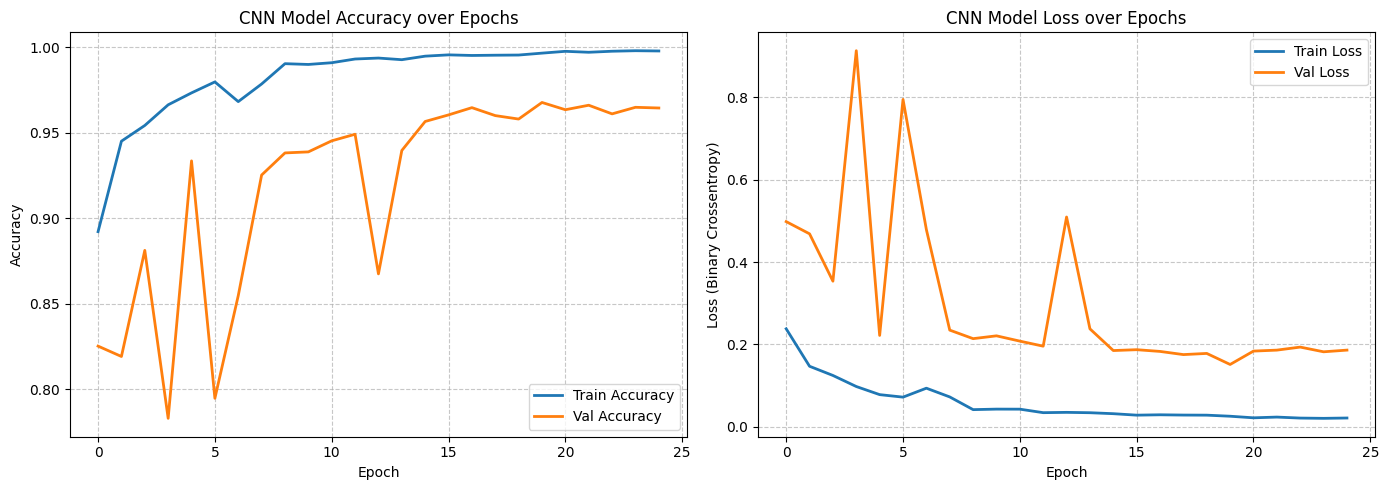

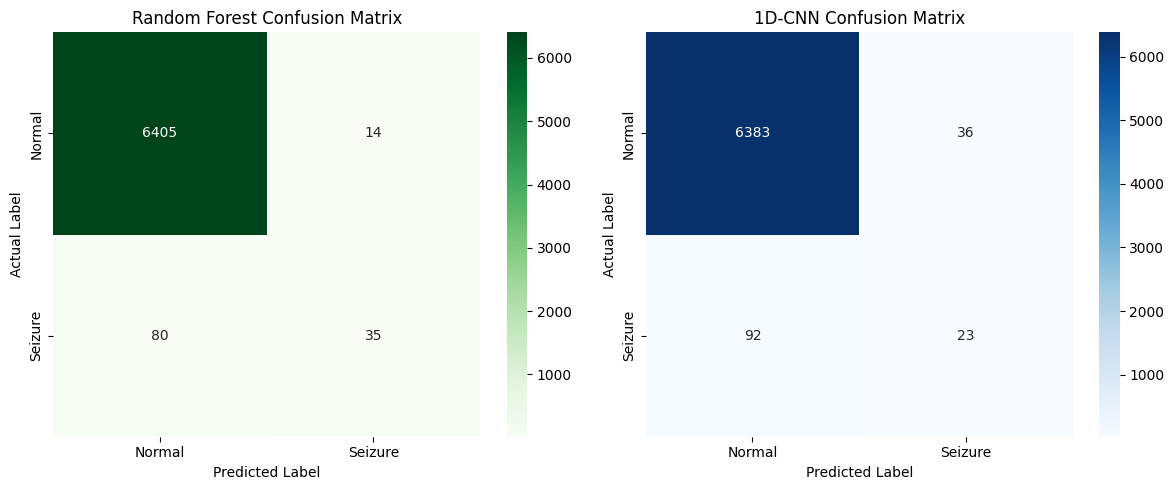

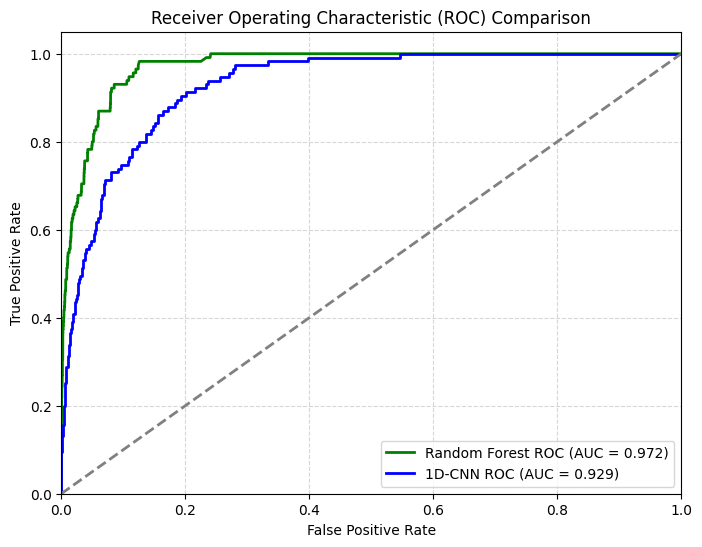

In [19]:
print("Generating Performance Visualizations...")

# --- 1. CNN TRAINING HISTORY ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
plt.title('CNN Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('CNN Model Loss over Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. CONFUSION MATRICES (Side-by-Side) ---
rf_cm = confusion_matrix(y_test, best_rf_pred)
cnn_cm = confusion_matrix(y_test, cnn_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# CNN Confusion Matrix
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
axes[1].set_title('1D-CNN Confusion Matrix')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# --- 3. ROC CURVES (Combined) ---
plt.figure(figsize=(8, 6))

# Random Forest ROC
plt.plot(best_rf_fpr, best_rf_tpr, color='green', lw=2, 
         label=f'Random Forest ROC (AUC = {best_rf_auc:.3f})')

# CNN ROC
plt.plot(cnn_fpr, cnn_tpr, color='blue', lw=2, 
         label=f'1D-CNN ROC (AUC = {cnn_auc:.3f})')

# Random Guess Diagonal
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# STEP 16: SAVE EVERYTHING

In [20]:
# Fixed: Saving to .keras format to prevent the legacy HDF5 warning
advanced_model.save('advanced_model.keras')
joblib.dump(history.history, 'training_history.pkl')

# Fixed: Calculating totals using train and test arrays since raw y was deleted
metrics = {
    'dataset_info': {
        'total_windows'  : int(len(y_train) + len(y_test)),
        'normal_samples' : int((y_train == 0).sum() + (y_test == 0).sum()),
        'seizure_samples': int((y_train == 1).sum() + (y_test == 1).sum()),
        'num_files'      : 142,  # Taken from Step 3 outputs
        'data_source'    : 'CHB-MIT (5 patients)',
    },
    'train_test_split': {
        'train_samples': int(len(y_train)),
        'test_samples' : int(len(y_test)),
        'split_method' : 'GroupShuffleSplit (patient-aware)',
    },
    'random_forest': {
        'test_acc' : float(best_rf_acc),
        'f1_score' : float(best_rf_f1),
        'roc_auc'  : float(best_rf_auc),
    },
    'cnn_1d': {
        'test_acc' : float(cnn_test_acc),
        'f1_score' : float(cnn_f1),
        'roc_auc'  : float(cnn_auc),
    },
}
joblib.dump(metrics, 'model_metrics.pkl')

print("\n✅ All files saved:")
print("   scaler.pkl")
print("   best_rf_tuned_model.pkl")
print("   advanced_model.keras")
print("   model_metrics.pkl")
print(f"\n🎉 TRAINING COMPLETE! Ready for app.py")


✅ All files saved:
   scaler.pkl
   best_rf_tuned_model.pkl
   advanced_model.keras
   model_metrics.pkl

🎉 TRAINING COMPLETE! Ready for app.py
